<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab6/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 6: Relación entre el S&P500 y el VIX**

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

## **Pregunta 1**

Descarga datos desde *Yahoo Finance* del VIX y del S&P500 para el período 01/01/2015 y 30/08/2026.

> **Nota:** *El VIX (Índice de Volatilidad del CBOE) mide la expectativa del mercado sobre la volatilidad a corto plazo (próximos 30 días) del índice S&P 500. Se calcula mediante una media ponderada de la volatilidad implícita obtenida a partir de los precios de las opciones sobre el índice S&P500.*

Se recomienda revisar:

*Whaley, R. 2009. Understanding the VIX. Journal of Portfolio Management, Spring, vol.35(3).*

In [2]:
# 1. Obtención de datos desde Yahoo Finance
tickers = ['^GSPC', '^VIX']
df = yf.download(tickers, start='2015-01-02', end='2026-08-31', interval='1d', auto_adjust=True, progress=False,)['Close']

## **Pregunta 2**

¿Cuáles son las primeras 10 y las últimas 10 observaciones?

In [ ]:
df.head(10)

Ticker,^GSPC,^VIX
Date,,
2015-01-02,2058.199951,17.790001
2015-01-05,2020.579956,19.920000
2015-01-06,2002.609985,21.120001
2015-01-07,2025.900024,19.309999
2015-01-08,2062.139893,17.010000
2015-01-09,2044.810059,17.549999
2015-01-12,2028.260010,19.600000
2015-01-13,2023.030029,20.559999
2015-01-14,2011.270020,21.480000


In [ ]:
df.tail(10)

Ticker,^GSPC,^VIX
Date,,
2026-08-17,7745.060059,15.19
2026-08-18,7691.759766,15.84
2026-08-19,7707.979980,14.89
2026-08-20,7641.160156,16.01
2026-08-21,7674.370117,15.13
2026-08-24,7652.859863,15.85
2026-08-25,7677.279785,15.45
2026-08-26,7675.700195,15.21
2026-08-27,7730.990234,14.51


## **Pregunta 3**

Construye un gráfico de línea que muestre la evolución del *S&P500* y *VIX*.

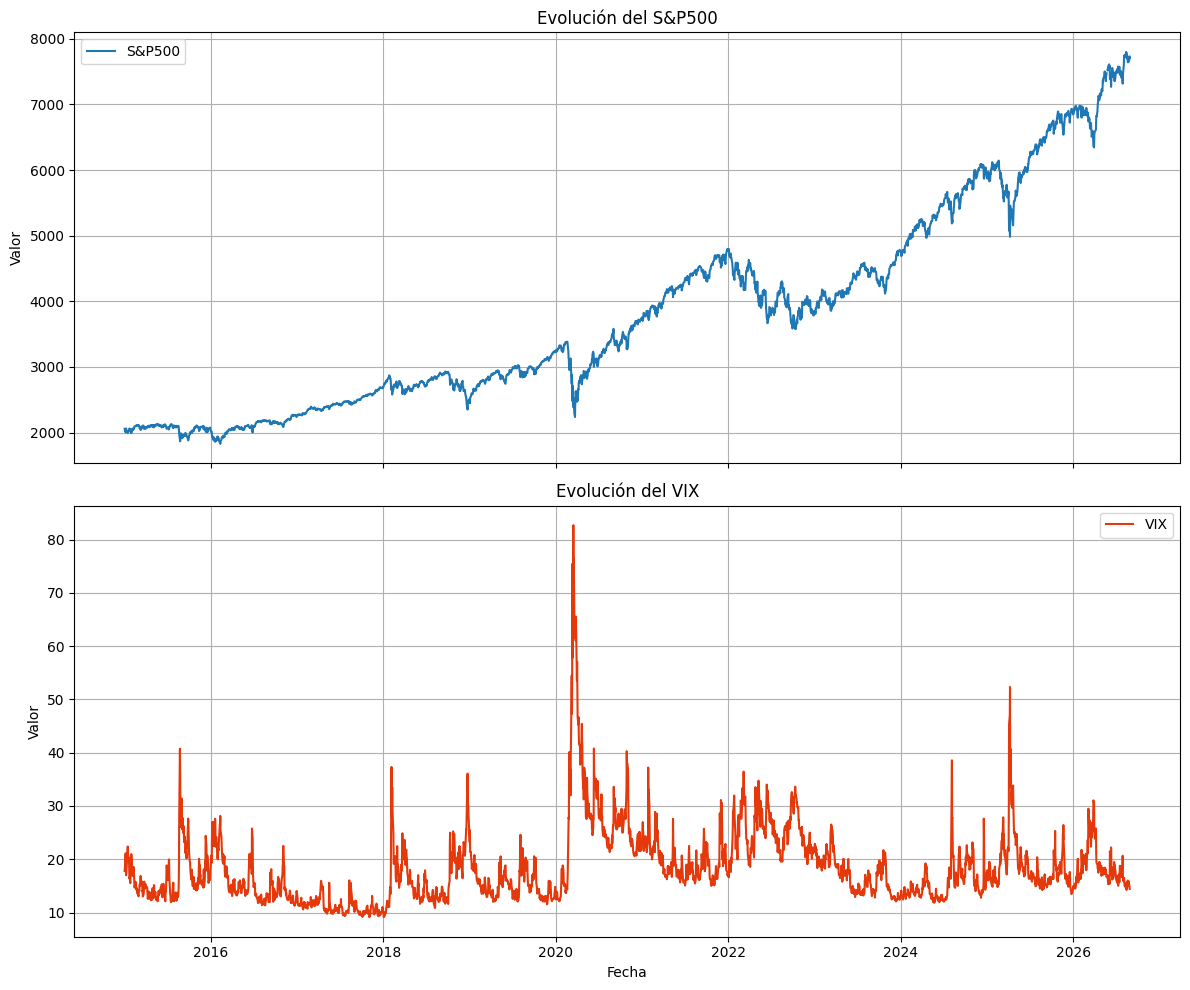

In [3]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# Plot S&P500
axes[0].plot(df['^GSPC'], label='S&P500')
axes[0].set_title('Evolución del S&P500')
axes[0].set_ylabel('Valor')
axes[0].legend()
axes[0].grid(True)

# Plot VIX
axes[1].plot(df['^VIX'], label='VIX', color='#E5380B')
axes[1].set_title('Evolución del VIX')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **Pregunta 4**

Calcula la variación porcentual diaria de ambos índices.

In [4]:
df["Retorno_SP500"] = df["^GSPC"].pct_change()
df["C_VIX"] = df["^VIX"].pct_change()
df = df.dropna()

/tmp/ipykernel_458/1026034368.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["Retorno_SP500"] = df["^GSPC"].pct_change()


In [ ]:
df.head(10)

Ticker,^GSPC,^VIX,Retorno_SP500,C_VIX
Date,,,,
2015-01-05,2020.579956,19.920000,-0.018278,0.119730
2015-01-06,2002.609985,21.120001,-0.008893,0.060241
2015-01-07,2025.900024,19.309999,0.011630,-0.085701
2015-01-08,2062.139893,17.010000,0.017888,-0.119109
2015-01-09,2044.810059,17.549999,-0.008404,0.031746
2015-01-12,2028.260010,19.600000,-0.008094,0.116809
2015-01-13,2023.030029,20.559999,-0.002579,0.048980
2015-01-14,2011.270020,21.480000,-0.005813,0.044747
2015-01-15,1992.670044,22.389999,-0.009248,0.042365


In [ ]:
df.tail(10)

Ticker,^GSPC,^VIX,Retorno_SP500,C_VIX
Date,,,,
2026-08-17,7745.060059,15.19,-0.005227,0.065965
2026-08-18,7691.759766,15.84,-0.006882,0.042791
2026-08-19,7707.979980,14.89,0.002109,-0.059975
2026-08-20,7641.160156,16.01,-0.008669,0.075218
2026-08-21,7674.370117,15.13,0.004346,-0.054966
2026-08-24,7652.859863,15.85,-0.002803,0.047588
2026-08-25,7677.279785,15.45,0.003191,-0.025237
2026-08-26,7675.700195,15.21,-0.000206,-0.015534
2026-08-27,7730.990234,14.51,0.007203,-0.046022


## **Pregunta 5**

Calcula la coeficiente de correlación entre las variaciones porcentuales diarias del VIX y del S&P500.

In [5]:
correlation = df['C_VIX'].corr(df['Retorno_SP500'])
print(f"Coeficiente de correlación entre C_VIX y Retorno_SP500: {correlation:.4f}")

Coeficiente de correlación entre C_VIX y Retorno_SP500: -0.7276


## **Pregunta 6**

Construye un gráfico de dispersión que muestre las variaciones porcentuales del CIX y S&P500.

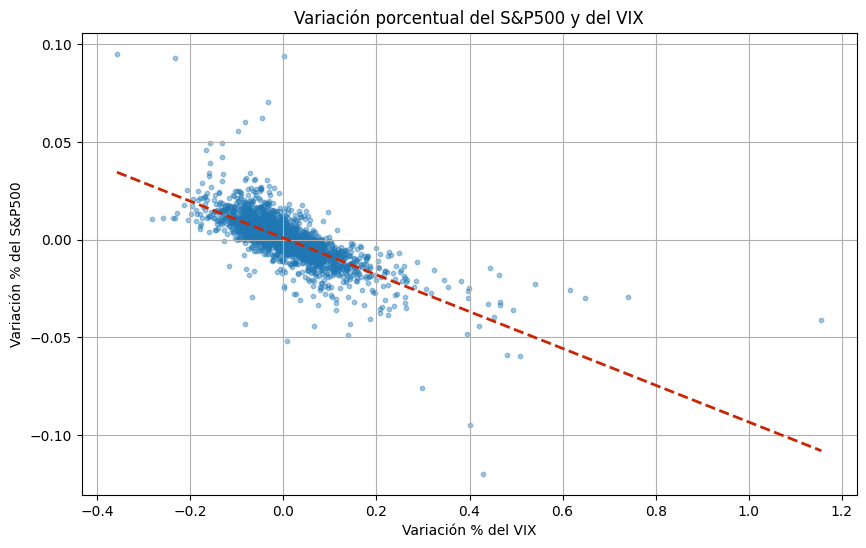

In [6]:
plt.figure(figsize=(10, 6))
sns.regplot(x=df['C_VIX'], y=df['Retorno_SP500'],
            scatter_kws={'alpha':0.4, 's':10},
            line_kws={'color':'#C92606', 'lw':2, 'linestyle':'--'}, ci=None)
plt.title('Variación porcentual del S&P500 y del VIX')
plt.xlabel('Variación % del VIX')
plt.ylabel('Variación % del S&P500')
plt.grid(True)
plt.show()

## **Pregunta 7**

Estima el siguiente modelo:

$$Ret_{SP500,t}=\delta_0+\delta_1\Delta_{VIX,t}+u_t$$

donde:

$\Delta_{VIX,t}$ es el cambio porcentual diario del VIX en el momento $t$.

$Ret_{SP500, t}$ es el retorno porcentual diario positivo del S&P500 en el momento $t$

¿Qué puedes concluir sobre la asociación entre el VIX y el S&P 500? ¿Sirve esta especificación para predecir el mercado?

In [7]:
X = sm.add_constant(df["C_VIX"])  # Variable independiente
y = df["Retorno_SP500"]  # Variable dependiente

In [8]:
model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          Retorno_SP500   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     3294.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:54:31   Log-Likelihood:                 10123.
No. Observations:                2930   AIC:                        -2.024e+04
Df Residuals:                    2928   BIC:                        -2.023e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      5.825      0.0

In [9]:
model1_hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model1_hac.summary())

                            OLS Regression Results                            
Dep. Variable:          Retorno_SP500   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     221.6
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           2.31e-48
Time:                        21:54:36   Log-Likelihood:                 10123.
No. Observations:                2930   AIC:                        -2.024e+04
Df Residuals:                    2928   BIC:                        -2.023e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      7.072      0.0

> **Nota 1:** *Los coeficientes no cambian al aplicar HAC respecto a MCO estándar. Fue necesario ajustar el modelo con `cov_type='HAC'`, porque MCO tradicional asume residuos independientes e idénticamente distribuidos. Al haber autocorrelación y heterocedasticidad, los errores estándar MCO habrían estado sesgados, haciendo que los intervalos de confianza y p-values fueran poco fiables para la toma de decisiones de inversión.*

> **Nota 2:** *El $R^2$ es el cuadrado del coeficiente de correlación entre las variaciones porcentuales diarias de ambos índices: $R^2=(-0.7276)^2=0.53$*

> **Pregunta:** *A la luz del $R^2=52.9\%$ y $\hat\delta_1=-0.0942$ obtenidos en la regresión, queda demostrado que, ante un disparo intradiario del $VIX$, un inversionista debe liquidar inmediatamente su posición en el S&P 500 para evitar pérdidas. ¿Estás de acuerdo con esta recomendación de *trading*?*

## **Pregunta 8**

Estima el siguiente modelo:

$$\Delta_{VIX,t}=\beta_0+\beta_1Ret_{SP500,t}+\epsilon_t$$

¿Cuál es la sensibilidad de los cambios en el VIX frente a los rendimientos del S&P 500? Interpreta $\beta_1$

In [10]:
X = sm.add_constant(df["Retorno_SP500"])  # Variable independiente
y = df["C_VIX"]  # Variable dependiente

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  C_VIX   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     3294.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:54:40   Log-Likelihood:                 4134.1
No. Observations:                2930   AIC:                            -8264.
Df Residuals:                    2928   BIC:                            -8252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0062      0.001      5.655

> **Nota:** *En esta especificación el VIX reacciona de manera perfectamente simétrica ante un aumento o disminución del S&P500.*

## **Pregunta 9**

(a) Estima el siguiente modelo que captura la *reacción asimétrica* a variaciones porcentuales positivas y negativas del S&P500:

$$\Delta_{VIX,t} = \gamma_0 + \gamma_1 Ret_{SP500, Pos, t} + \gamma_2 Ret_{SP500, Neg, t} + \epsilon_t $$

donde:

$Ret_{SP500, Pos, t}$ es el retorno porcentual diario positivo del S&P500 en el momento $t$ (si el retorno es negativo, esta variable es 0).

$Ret_{SP500, Neg, t}$ es el retorno porcentual diario negativo del S&P500 en el momento $t$ (si el retorno es positivo, esta variable es 0).

$\epsilon_t$ es el término de error.

(b) Testea la siguiente hipótesis:

$H_0:\gamma_1=\gamma_2$

$H_1:\gamma_1 \neq \gamma_2$

Usando un nivel de significancia de 5% ¿qué puedes concluir?


In [11]:
df['Retorno_SP500_Pos'] = np.where(df['Retorno_SP500'] > 0, df['Retorno_SP500'], 0)
df['Retorno_SP500_Neg'] = np.where(df['Retorno_SP500'] < 0, df['Retorno_SP500'], 0)

df.head(10)

Ticker,^GSPC,^VIX,Retorno_SP500,C_VIX,Retorno_SP500_Pos,Retorno_SP500_Neg
Date,,,,,,
2015-01-05,2020.579956,19.920000,-0.018278,0.119730,0.000000,-0.018278
2015-01-06,2002.609985,21.120001,-0.008893,0.060241,0.000000,-0.008893
2015-01-07,2025.900024,19.309999,0.011630,-0.085701,0.011630,0.000000
2015-01-08,2062.139893,17.010000,0.017888,-0.119109,0.017888,0.000000
2015-01-09,2044.810059,17.549999,-0.008404,0.031746,0.000000,-0.008404
2015-01-12,2028.260010,19.600000,-0.008094,0.116809,0.000000,-0.008094
2015-01-13,2023.030029,20.559999,-0.002579,0.048980,0.000000,-0.002579
2015-01-14,2011.270020,21.480000,-0.005813,0.044747,0.000000,-0.005813
2015-01-15,1992.670044,22.389999,-0.009248,0.042365,0.000000,-0.009248


In [12]:
X_asym = sm.add_constant(df[['Retorno_SP500_Pos', 'Retorno_SP500_Neg']])
y_asym = df['C_VIX']

# Estimar el modelo
model3 = sm.OLS(y_asym, X_asym).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  C_VIX   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     1839.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:54:48   Log-Likelihood:                 4222.2
No. Observations:                2930   AIC:                            -8438.
Df Residuals:                    2927   BIC:                            -8420.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0062      0.00

(b) El test de hipótesis se realiza a continuación:

In [13]:
hypothesis = 'Retorno_SP500_Pos - Retorno_SP500_Neg = 0'
f_test_result = model3.f_test(hypothesis)

print(f_test_result)

<F test: F=181.22532645124767, p=3.99111109148906e-40, df_denom=2.93e+03, df_num=1>


Dado que el p-value es mucho menor que el nivel de significancia de 5% (0.05), se rechaza $H_0$. Esto significa que la reacción del VIX a los retornos positivos del S&P500 es estadísticamente diferente de su reacción a los retornos negativos, lo que confirma la presencia de un *efecto asimétrico* en la respuesta del VIX a los movimientos del mercado.

> **Nota:** *El resultado muestra que hay una fuerte *reacción asimétrica*: las caídas en el S&P500 (retornos negativos) provocan un aumento mucho más pronunciado en el VIX que la disminución del VIX causada por un aumento de igual magnitud en el S&P500 (retornos positivos).*


## **Pregunta 10**

Otra forma de plantear el modelo de regresión lineal para capturar la reacción asimétrica a variaciones porcentuales es la siguiente:

$$\Delta_{VIX,t}=\beta_0+\beta_1Ret_{SP500,t}+\beta_2Ret_{SP500,t}\times D_t+\epsilon_t$$

donde $D_t$ es una variable dummy que toma el valor 1 si el retorno es positivo y 0, en otro caso,

In [14]:
# Crear la variable dummy Dt
df['Dt'] = np.where(df['Retorno_SP500'] > 0, 1, 0)

# Crear el término de interacción
df['Retorno_SP500_x_Dt'] = df['Retorno_SP500'] * df['Dt']

# Preparación de Variables para la Regresión OLS (Modelo Asimétrico con Dummy)
X_asym_dummy = sm.add_constant(df[['Retorno_SP500', 'Retorno_SP500_x_Dt']])
y_asym_dummy = df['C_VIX']

# Estimar el modelo
model4 = sm.OLS(y_asym_dummy, X_asym_dummy).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  C_VIX   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     89.98
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           1.19e-38
Time:                        21:54:55   Log-Likelihood:                 4222.2
No. Observations:                2930   AIC:                            -8438.
Df Residuals:                    2927   BIC:                            -8420.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0062      0